In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

In [ ]:
model = VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


In [ ]:
def deprocess_input(img_tensor):
    img = img_tensor.numpy()
    img = (img + 1.0) / 2.0
    img = np.clip(img, 0, 1)
    return img

In [ ]:
def load_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    input_img = np.expand_dims(img_array, axis=0)
    return preprocess_input(input_img), img_array.astype(np.uint8)

In [ ]:
img_path = tf.keras.utils.get_file("elephant.jpg", "https://www.kenyatourism.in/images/african-elephant-amboseli.jpg")
# img_path = 'elephant.png'
preprocessed_img, raw_img = load_image(img_path)

preds = model.predict(preprocessed_img)
top_pred_idx = tf.argmax(preds[0])
print("Predicted:", decode_predictions(preds, top=1)[0])

28858/28858 ━━━━━━━━━━━━━━━━━━━━ 0s 7us/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Predicted: [('n02504458', 'African_elephant', np.float32(0.49474785))]


In [ ]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

In [ ]:
def create_adversarial_pattern(image, label_index):
    image = tf.convert_to_tensor(image)
    label_index = tf.convert_to_tensor(label_index)
    label_index = tf.cast(label_index, tf.int32)

    label = tf.one_hot(label_index, 1000)
    label = tf.reshape(label, (1, 1000))

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = loss_object(label, prediction)

    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    return signed_grad

In [ ]:
perturbations = create_adversarial_pattern(preprocessed_img, top_pred_idx)
epsilon = 0.01
adv_img = preprocessed_img + epsilon * perturbations
adv_img = tf.clip_by_value(adv_img, -1, 1)

In [ ]:
def get_gradcam_heatmap(img, model, layer_name='block5_conv3', class_index=None, use_softmax=False):
    grad_model = tf.keras.Model([model.inputs], [model.get_layer(layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        if class_index is None:
            class_index = tf.argmax(predictions[0])

        if use_softmax:
            probs = tf.nn.softmax(predictions)
            loss = probs[:, class_index]
        else:
            loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap + 1e-6)
    return heatmap.numpy()

In [ ]:
def compute_integrated_gradients(model, baseline, image, class_index, steps=50, use_softmax=False):
    baseline = tf.squeeze(baseline)
    image = tf.squeeze(image)

    interpolated = [
        baseline + (float(i) / steps) * (image - baseline)
        for i in range(steps + 1)
    ]
    interpolated = tf.convert_to_tensor(interpolated)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        output = model(interpolated)
        if use_softmax:
            output = tf.nn.softmax(output)
        probs = output[:, class_index]

    grads = tape.gradient(probs, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0)
    ig = (image - baseline) * avg_grads
    return tf.reduce_sum(tf.math.abs(ig), axis=-1).numpy()

In [ ]:
heatmap_orig = get_gradcam_heatmap(preprocessed_img, model)
heatmap_adv = get_gradcam_heatmap(adv_img, model)

baseline = tf.zeros_like(preprocessed_img)
ig_orig = compute_integrated_gradients(model, baseline, preprocessed_img, top_pred_idx)
ig_adv = compute_integrated_gradients(model, baseline, adv_img, tf.argmax(model.predict(adv_img)[0]))

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [ ]:
pred_orig = model.predict(preprocessed_img)
decoded_orig = tf.keras.applications.vgg16.decode_predictions(pred_orig, top=1)[0]

pred_adv = model.predict(adv_img)
decoded_adv = tf.keras.applications.vgg16.decode_predictions(pred_adv, top=1)[0]

print("Original Image Prediction:")
for cls, name, prob in decoded_orig:
    print(f"{name} ({cls}): {prob:.4f}")

print("\nAdversarial Image Prediction:")
for cls, name, prob in decoded_adv:
    print(f"{name} ({cls}): {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Original Image Prediction:
African_elephant (n02504458): 0.4947

Adversarial Image Prediction:
mosquito_net (n03788365): 0.0940


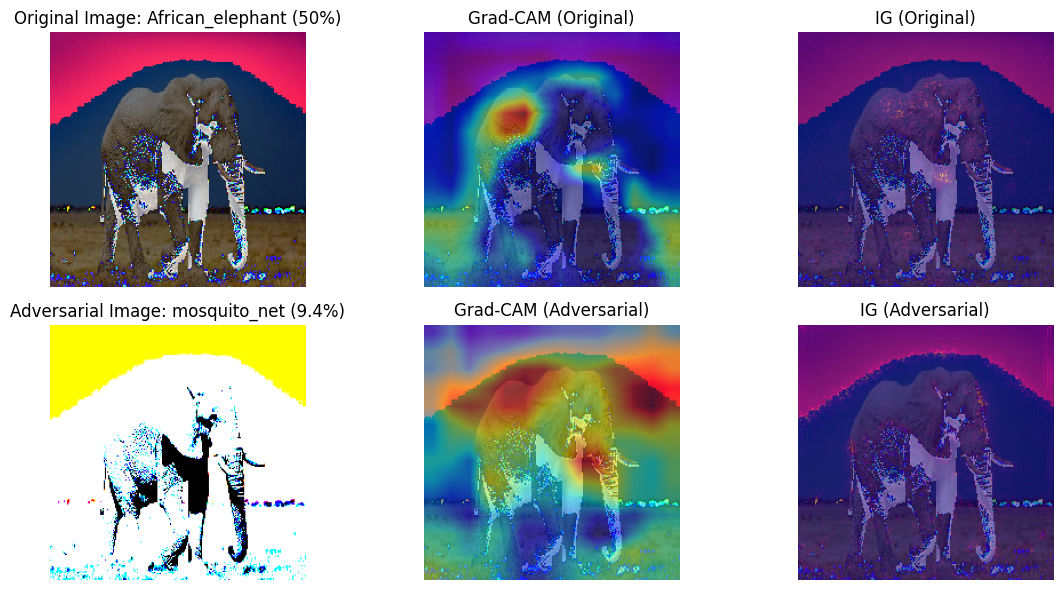

In [ ]:
def plot_result(img, heatmap, title, cmap='jet'):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap=cmap, alpha=0.5)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.imshow(raw_img / 255.0)
plt.title("Original Image: African_elephant (50%)")
plt.axis('off')

plt.subplot(2, 3, 2)
plot_result(raw_img, heatmap_orig, "Grad-CAM (Original)")

plt.subplot(2, 3, 3)
plot_result(raw_img, ig_orig, "IG (Original)", cmap='plasma')

plt.subplot(2, 3, 4)
plt.imshow(deprocess_input(adv_img[0]))
plt.title("Adversarial Image: mosquito_net (9.4%)")
plt.axis('off')

plt.subplot(2, 3, 5)
plot_result(raw_img, heatmap_adv, "Grad-CAM (Adversarial)")

plt.subplot(2, 3, 6)
plot_result(raw_img, ig_adv, "IG (Adversarial)", cmap='plasma')

plt.tight_layout()
plt.show()


In [ ]:
def show_comparison(raw_img, adv_img, gradcam_orig, gradcam_adv, ig_orig, ig_adv, decoded_orig, decoded_adv):
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))

    axs[0, 0].imshow(raw_img / 255.0)
    axs[0, 0].set_title(f"Original\n{decoded_orig[0][1]} ({decoded_orig[0][2]*100:.1f}%)")
    axs[0, 0].axis('off')

    axs[0, 1].imshow(raw_img / 255.0)
    axs[0, 1].imshow(tf.image.resize(gradcam_orig[..., np.newaxis], (224, 224)).numpy().squeeze(), cmap='jet', alpha=0.5)
    axs[0, 1].set_title("Grad-CAM (Original)")
    axs[0, 1].axis('off')

    axs[0, 2].imshow(raw_img / 255.0)
    axs[0, 2].imshow(ig_orig, cmap='hot', alpha=0.6)
    axs[0, 2].set_title("IG (Original)")
    axs[0, 2].axis('off')

    axs[0, 3].imshow(np.abs(ig_orig - ig_adv), cmap='viridis')
    axs[0, 3].set_title("IG Difference")
    axs[0, 3].axis('off')

    # Row 2: Adversarial Image
    adv_show = deprocess_input(tf.squeeze(adv_img))
    axs[1, 0].imshow(adv_show)
    axs[1, 0].set_title(f"Adversarial\n{decoded_adv[0][1]} ({decoded_adv[0][2]*100:.1f}%)")
    axs[1, 0].axis('off')

    axs[1, 1].imshow(adv_show)
    axs[1, 1].imshow(tf.image.resize(gradcam_adv[..., np.newaxis], (224, 224)).numpy().squeeze(), cmap='jet', alpha=0.5)
    axs[1, 1].set_title("Grad-CAM (Adversarial)")
    axs[1, 1].axis('off')

    axs[1, 2].imshow(adv_show)
    axs[1, 2].imshow(ig_adv, cmap='hot', alpha=0.6)
    axs[1, 2].set_title("IG (Adversarial)")
    axs[1, 2].axis('off')

    axs[1, 3].imshow(np.abs(gradcam_orig - gradcam_adv), cmap='magma')
    axs[1, 3].set_title("Grad-CAM Difference")
    axs[1, 3].axis('off')

    plt.tight_layout()
    plt.show()


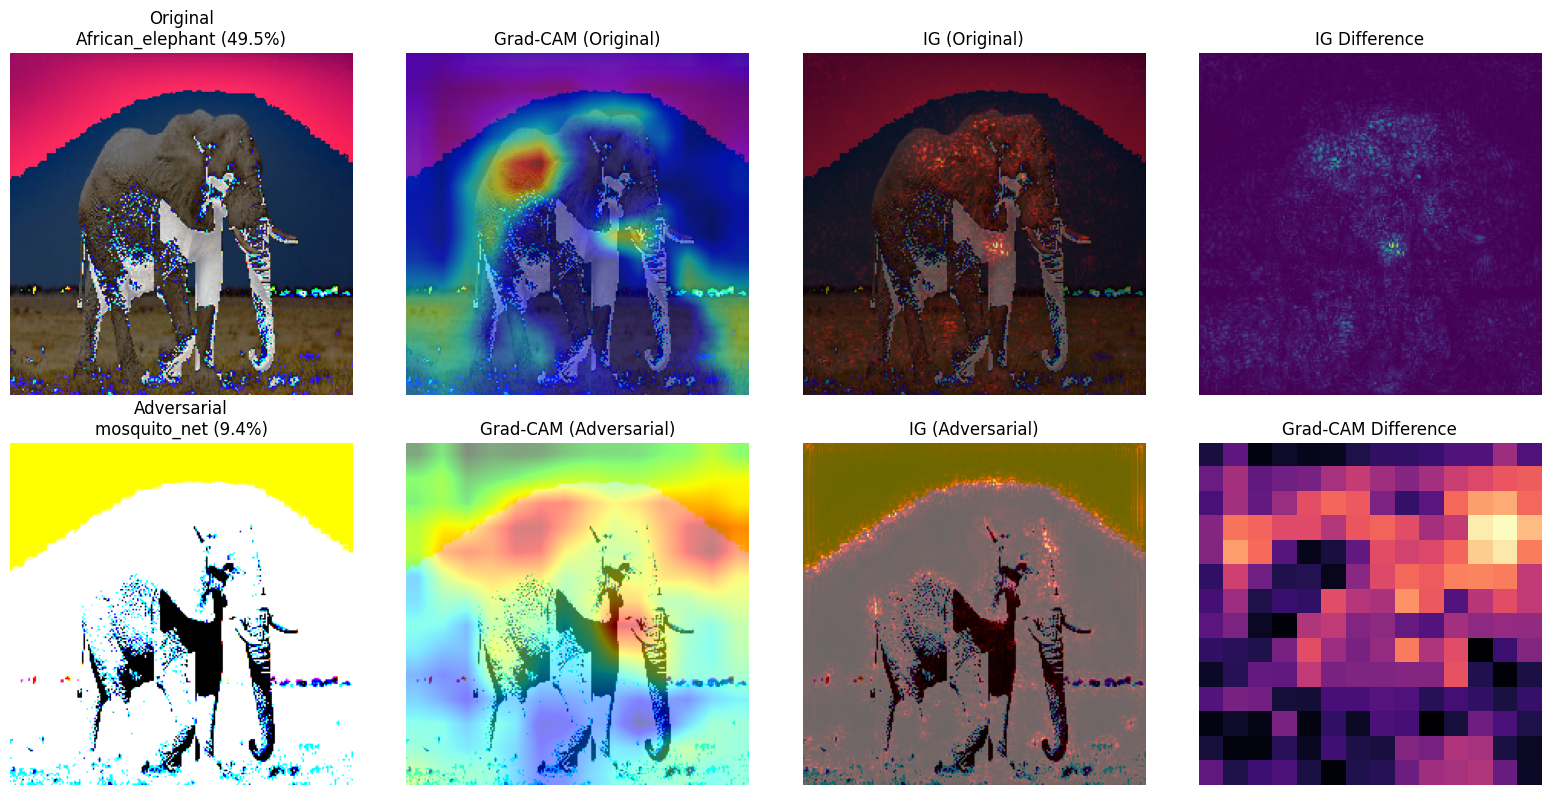

In [ ]:
show_comparison(raw_img, adv_img, heatmap_orig, heatmap_adv, ig_orig, ig_adv, decoded_orig, decoded_adv)


In [ ]:
gc_logits = get_gradcam_heatmap(preprocessed_img, model, use_softmax=False)
gc_softmax = get_gradcam_heatmap(preprocessed_img, model, use_softmax=True)

ig_logits = compute_integrated_gradients(model, baseline, preprocessed_img, top_pred_idx, use_softmax=False)
ig_softmax = compute_integrated_gradients(model, baseline, preprocessed_img, top_pred_idx, use_softmax=True)


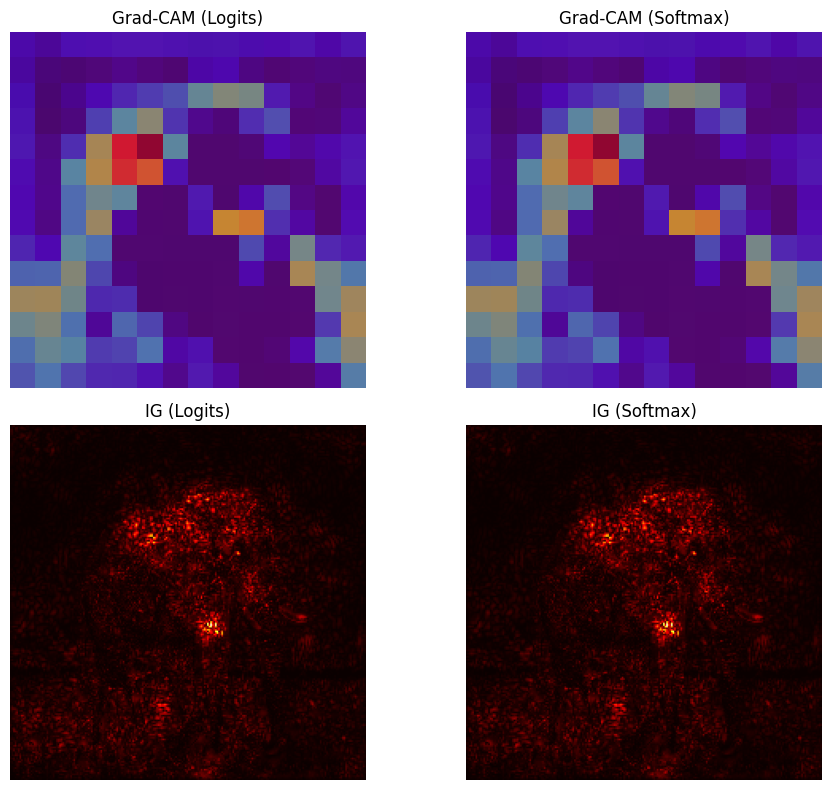

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].imshow(raw_img / 255.0)
axs[0, 0].imshow(gc_logits, cmap='jet', alpha=0.5)
axs[0, 0].set_title("Grad-CAM (Logits)")
axs[0, 0].axis('off')

axs[0, 1].imshow(raw_img / 255.0)
axs[0, 1].imshow(gc_softmax, cmap='jet', alpha=0.5)
axs[0, 1].set_title("Grad-CAM (Softmax)")
axs[0, 1].axis('off')

axs[1, 0].imshow(ig_logits, cmap='hot')
axs[1, 0].set_title("IG (Logits)")
axs[1, 0].axis('off')

axs[1, 1].imshow(ig_softmax, cmap='hot')
axs[1, 1].set_title("IG (Softmax)")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()
